In [1]:
import os
import qsprpred
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a depende

In [2]:
def load_datasets(path):
    dataset = QSPRDataset.fromTableFile(
    filename=path,
    store_dir="dataset_outputs/A2AR/data",
    name="A2ARDataset",
    target_props=[{"name": "Y", "task": "SINGLECLASS", "th": [0.5]}],
    random_state=42,
    smiles_col = 'Drug',
    sep=','
    )
    #dataset.prepareDataset(
    #feature_calculators=[MorganFP(radius=2, nBits=1024)],
    #recalculate_features=True,
    #shuffle=False
    #)
    #from qsprpred.data.descriptors.sets import RDKitDescs
    
    #rdkit_descs = RDKitDescs()
    
    #dataset.addDescriptors([rdkit_descs])
    
    #dataset.descriptorSets
    return dataset
    

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X1_all = load_datasets("CK1/data/ck1_train_1")

X2_all = load_datasets("CK1/data/ck1_val_1")

X3_all = load_datasets("CK1/data/ck1_test_1")


In [4]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

class Dataset_creator():
    def __init__(self, model_names=['RoBERTa_ZINC'], corr_thrsh= 0.95):
        self.variance = VarianceThreshold(threshold=0.0)
        self.model_names = model_names
        self.corr_thrsh = corr_thrsh
        self.selected_indices = None
        
    def fit_transform(self, dataset):
        dataset.prepareDataset(feature_calculators=[MorganFP(radius=2, nBits=1024)], recalculate_features=True, shuffle=False)
        rdkit_descs = RDKitDescs()
        dataset.addDescriptors([rdkit_descs])
        display(dataset.X.shape)
        
        dataset.descriptorSets
        dataset_embs = self.create_embs(dataset)
        dataset_embs.index = dataset.X.index
        dataset.X = pd.concat([dataset.X, dataset_embs], axis=1)
        display(dataset.X.shape)
        
        dataset_no_var_np = self.variance.fit_transform(dataset.X)
        mask = self.variance.get_support()
        dataset_without_no_var = pd.DataFrame(
            dataset_no_var_np,
            columns=dataset.X.columns[mask],
            index=dataset.X.index)
        display(dataset_without_no_var.shape)

        
        dataset_without_high_corr = self.high_correlation(dataset_without_no_var)
        display(dataset_without_high_corr.shape)
        
        dataset.X = dataset_without_high_corr
        return dataset
        
    def transform(self, dataset):
        dataset.prepareDataset(feature_calculators=[MorganFP(radius=2, nBits=1024)], recalculate_features=True, shuffle=False)
        rdkit_descs = RDKitDescs()
        dataset.addDescriptors([rdkit_descs])
        display(dataset.X.shape)

        dataset.descriptorSets
        dataset_embs = self.create_embs(dataset)
        dataset_embs.index = dataset.X.index
        dataset.X = pd.concat([dataset.X, dataset_embs], axis=1)
        display(dataset.X.shape)

        dataset_no_var_np = self.variance.transform(dataset.X)
        mask = self.variance.get_support()
        dataset_without_no_var = pd.DataFrame(
            dataset_no_var_np,
            columns=dataset.X.columns[mask],
            index=dataset.X.index)
        display(dataset_without_no_var.shape)

        dataset_without_high_corr = dataset_without_no_var[self.selected_indices]
        display(dataset_without_high_corr.shape)

        dataset.X = dataset_without_high_corr
        return dataset

    def high_correlation(self, df: pd.DataFrame):
        corr_matrix = df.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        
        to_drop = [column for column in upper.columns if any(upper[column] > self.corr_thrsh)]
        self.selected_indices = df.columns.difference(to_drop)
        
        return df[self.selected_indices]

        
    def create_embs(self, dataset):
        dataset.df["SMILES"] = dataset.df["Drug"]
        final_emb = pd.DataFrame()
        for model_name in self.model_names:
            extractor = MolEmb.EmbeddingExtractor(model_name=model_name, df=dataset.df)
            new_emb, dataset.df = extractor.get_embeddings()
            display(type(new_emb))
            if final_emb.empty:
                final_emb = new_emb
            else:
                final_emb = pd.concat([final_emb, new_emb], axis=1)
        final_emb.columns = final_emb.columns.astype(str)
        display(final_emb)
        return final_emb
    


In [5]:
cls = Dataset_creator(['Mol2Vec', 'RoBERTa_ZINC'])

In [6]:
X1_all = cls.fit_transform(X1_all)
X2_all = cls.transform(X2_all)
X3_all = cls.transform(X3_all)

(488, 1234)

pandas.core.frame.DataFrame

Some weights of RobertaModel were not initialized from the model checkpoint at entropy/roberta_zinc_480m and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


pandas.core.frame.DataFrame

,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
0,2.516871,0.534238,-2.452955,7.686741,0.431078,-0.694065,-12.601948,-0.971291,7.476032,3.846928,...,-0.143628,0.515095,-0.074862,-0.102673,0.103030,0.130476,0.499113,-0.214322,-0.077564,-0.431823
1,6.052453,-2.925424,-2.070877,8.495329,1.301863,1.117611,-16.032846,-1.642392,9.346370,2.927347,...,0.051274,0.277398,-0.593216,0.042848,-0.011813,0.098258,0.729520,-0.701225,0.259042,-0.592370
2,5.744293,-7.785055,-3.891767,11.262932,0.251325,0.310802,-16.780500,-1.574069,10.337992,5.297069,...,-0.086957,0.134045,0.056459,-0.335765,0.136977,0.272289,1.180151,-0.274104,0.327263,-0.534128
3,5.114468,-4.830433,-5.447062,10.757203,0.077670,0.495645,-12.574245,-2.077898,7.660981,3.149048,...,-0.250937,0.206534,-0.223312,0.343322,-0.241193,0.214450,1.021452,-0.288710,-0.215809,-0.786897
4,2.010692,-1.409427,-3.583793,3.778501,1.039966,-1.023768,-7.496891,-0.705993,5.007909,2.194638,...,0.054637,0.027199,-0.383653,0.068650,0.585950,-0.025223,0.926432,0.213663,-0.226463,-0.451652
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
483,3.387227,-3.312556,-3.568770,9.836091,-2.975115,-4.776808,-15.644789,0.402767,11.404202,5.728592,...,0.259191,-0.156011,-0.657177,0.090683,-0.131137,-0.044086,0.658195,-0.148066,-0.333033,-0.870234
484,2.365839,-5.633009,-3.388613,10.866866,-1.929445,0.710701,-15.617691,-1.977192,10.801051,3.905593,...,0.279238,0.092157,-0.210265,-0.054687,0.159311,0.148841,1.103577,-0.306556,0.361056,-0.596046
485,2.876224,-5.038481,-3.354145,4.159993,0.195354,-1.229711,-6.549203,0.585766,1.457568,0.045052,...,-0.088278,0.292331,-0.240328,-0.308141,-0.375836,-0.005479,0.483670,-0.645472,0.012842,-0.240922
486,3.581094,-6.064793,-2.769171,6.592866,-0.030812,-0.284410,-9.875506,0.379415,4.067562,0.976918,...,0.253126,0.356655,-0.030671,-0.108964,0.162669,0.056533,0.501798,-0.532637,-0.328418,-0.128803


...

pandas.core.frame.DataFrame

,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
0,4.884953,-7.157942,-5.138814,13.006714,-2.730479,0.151554,-20.335842,-2.198932,17.312227,6.219527,...,0.010942,0.226891,-0.549037,0.132376,0.037968,0.605839,0.911198,-0.137456,0.129961,-0.967576
1,3.740307,-6.143758,-2.042488,10.055068,-1.950604,2.415757,-14.389182,-1.108633,10.755788,3.516679,...,-0.014316,0.385896,-0.545804,0.038958,0.287735,0.626203,1.166353,-0.095385,-0.005796,-0.972924
2,2.931786,-4.380294,-4.727276,12.547298,-0.920773,0.859071,-14.014235,-1.219353,10.044724,4.105293,...,0.153847,0.328493,0.075381,0.357536,-0.166716,0.382348,1.111882,-0.605728,0.704239,-0.395475
3,2.763307,-3.071845,-4.337036,7.157831,1.675385,-0.164037,-14.796813,0.702609,8.210071,3.552740,...,0.043420,0.275199,-0.554195,-0.329015,-0.197298,0.412721,0.569449,-0.312527,-0.098183,-0.531841
4,5.317841,-3.904930,-5.222112,10.552648,-0.299198,0.792047,-13.066146,-1.410062,9.210221,4.334833,...,-0.297946,0.241099,-0.360677,0.370727,-0.181313,0.198411,1.087878,-0.556719,-0.322968,-0.667929
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,4.732400,-5.931112,-2.695037,7.379294,0.355767,1.439902,-9.418824,-0.047803,4.838798,0.808847,...,0.349798,0.256530,-0.020947,-0.335571,-0.034310,0.108234,0.765672,-0.501721,-0.253853,-0.082646
160,2.290391,-1.555030,-2.027585,5.427836,2.616212,1.212105,-11.124537,-0.277540,5.989487,-0.544919,...,0.083183,0.174510,-0.304669,-0.249486,0.221935,-0.219294,0.534043,-0.708747,-0.097672,0.005163
161,2.183160,-2.231052,-2.962017,7.712423,-0.278175,0.161704,-8.929571,-0.744787,6.846818,2.309243,...,-0.268816,0.230295,-0.299570,0.210466,0.212637,-0.155051,0.824359,-0.204696,0.053603,-0.599155
162,1.697251,-2.229853,-2.875325,7.633800,-0.657874,-0.268612,-8.608117,-0.441910,7.232983,2.815516,...,-0.106652,0.258743,-0.016806,-0.088005,0.264663,-0.236336,0.674913,-0.257922,0.189105,-0.678619


(164, 2302)

(164, 2251)

(164, 1606)

In [32]:
X1 = X1_all.X
y1 = X1_all.y
X2 = X2_all.X
y2 = X2_all.y
X3 = X3_all.X
y3 = X3_all.y

In [33]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [34]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=1, random_state=42)
X1, y1 = smote.fit_resample(X1, y1)
display(pd.DataFrame(X1))

,0,1,2,3,4,5,6,7,8,9,...,1596,1597,1598,1599,1600,1601,1602,1603,1604,1605
0,-0.296463,-1.014346,0.704087,0.197034,-0.199916,0.056990,-1.262282,-0.085669,-1.053805,0.296247,...,-0.120636,-0.322603,-0.237228,-0.06415,-0.078648,-0.160464,-0.331527,-0.101745,-0.294720,0.856668
1,-0.670941,-0.525577,-1.236676,1.502286,0.377970,-0.372174,-0.045401,-0.789457,0.021136,-0.509625,...,-0.120636,-0.322603,-0.237228,-0.06415,-0.078648,-0.160464,-0.331527,-0.101745,-0.294720,-0.299228
2,0.629879,0.514115,-0.293469,1.144866,-1.295461,-1.086432,1.400654,1.220583,1.660234,-0.789349,...,-0.120636,-0.322603,-0.237228,-0.06415,-0.078648,-0.160464,-0.331527,-0.101745,-0.294720,-0.866535
3,0.373012,-1.030634,0.820882,0.936072,-0.378374,1.713116,1.237002,-0.435967,-0.914606,1.251034,...,-0.120636,-0.322603,-0.237228,-0.06415,-0.078648,-0.160464,-0.331527,-0.101745,-0.294720,-0.567226
4,-1.172401,0.684663,-0.397464,-1.756755,1.804830,0.697231,-0.604966,-1.927427,-0.766635,-1.374831,...,-0.120636,-0.322603,-0.237228,-0.06415,-0.078648,-0.160464,-0.331527,-0.101745,-0.294720,1.510832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789,-1.193043,-0.487364,-0.908142,1.116066,-0.271553,-0.376130,-0.633162,0.123939,1.031423,0.226711,...,-0.120636,-0.322603,-0.237228,-0.06415,-0.078648,-0.160464,-0.331527,-0.101745,-0.294720,-0.918624
790,1.321930,1.287812,0.286024,0.196173,-1.279482,-0.556713,1.382801,-0.132985,-1.314422,0.429897,...,-0.120636,-0.322603,-0.237228,-0.06415,-0.078648,-0.160464,-0.331527,-0.101745,-0.294720,0.493789
791,-0.154973,-0.455318,-0.238099,0.904149,-0.407208,-0.450771,0.779598,-0.481580,0.781895,0.119625,...,-0.120636,-0.322603,-0.237228,-0.06415,-0.078648,-0.160464,-0.331527,-0.101745,-0.294720,-0.939608
792,-0.797940,-1.214398,0.379445,0.077084,-1.112721,0.245131,0.215236,0.163450,-0.060331,0.594680,...,-0.120636,-0.322603,-0.237228,-0.06415,-0.078648,-0.160464,-0.331527,-0.101745,3.393055,-0.478425


In [35]:
X1_all.X.shape

(488, 1606)

In [36]:
X1

array([[-0.296463  , -1.014346  ,  0.7040874 , ..., -0.10174461,
        -0.2947197 ,  0.85666835],
       [-0.67094135, -0.5255768 , -1.2366765 , ..., -0.10174461,
        -0.2947197 , -0.2992283 ],
       [ 0.6298792 ,  0.5141149 , -0.2934687 , ..., -0.10174461,
        -0.2947197 , -0.8665355 ],
       ...,
       [-0.1549728 , -0.45531818, -0.23809947, ..., -0.10174461,
        -0.2947197 , -0.9396076 ],
       [-0.7979405 , -1.2143979 ,  0.3794446 , ..., -0.10174461,
         3.3930547 , -0.4784247 ],
       [-0.90159816, -0.66431266, -0.9633243 , ..., -0.10174461,
        -0.2947197 , -0.46983036]], dtype=float32)

In [31]:
#X1.to_csv("qsprpred/extra/gpu/models/CK1/mod_data/X1.1")
#X2.to_csv("qsprpred/extra/gpu/models/CK1/mod_data/X2.1")
#y1.to_csv("qsprpred/extra/gpu/models/CK1/mod_data/y1.1")
#X3.to_csv("qsprpred/extra/gpu/models/CK1/mod_data/X3.1")
#y3.to_csv("qsprpred/extra/gpu/models/CK1/mod_data/y3.1")
#y2.to_csv("qsprpred/extra/gpu/models/CK1/mod_data/y2.1")

In [37]:
from sklearn.decomposition import PCA
pca = PCA(n_components=278)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

In [38]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1

In [39]:
n_components

274

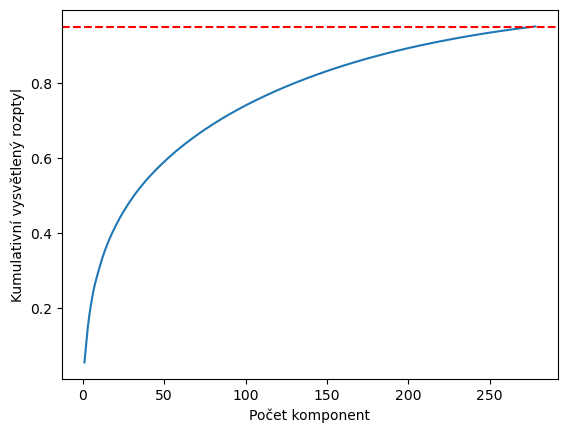

In [40]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [41]:
y1.sum()/y1.count()

Y    0.5
dtype: float64

In [42]:
X1_all.y.sum()/X1_all.y.count()

Y    0.186475
dtype: float64

In [47]:

# Přidejte cestu k vašemu lokálnímu repozitáři
import sys
import os

# Přidání cesty k lokálnímu repozitáři na začátek sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Zkontrolujte, zda je cesta v sys.path
print(sys.path)

from importlib import reload

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected
# Znovu načtěte modul, abyste zajistili, že je správně importován
reload(sys.modules['qsprpred.extra.gpu.models.neural_network'])

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected

os.chdir('/home/ubuntu/Bakalarka/QSPRpred')
print(os.getcwd())


import sys
import importlib.util

# Přidání cesty k repozitáři do sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Specifikujte cestu k souboru, který chcete importovat
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/neural_network.py'
module_name = 'qsprpred.extra.gpu.models.neural_network'

# Načtěte modul z konkrétní cesty
spec = importlib.util.spec_from_file_location(module_name, module_path)
neural_network = importlib.util.module_from_spec(spec)
spec.loader.exec_module(neural_network)

# Nyní můžete používat třídu STFullyConnected
STFullyConnected = neural_network.STFullyConnected

['/home/ubuntu/Bakalarka/QSPRpred', '/home/ubuntu/Bakalarka/QSPRpred', '/home/ubuntu/Bakalarka/QSPRpred', '/home/ubuntu/Bakalarka/QSPRpred', '/home/ubuntu/Bakalarka/QSPRpred', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python311.zip', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/lib-dynload', '', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages']
/home/ubuntu/Bakalarka/QSPRpred
lol


In [48]:
from sklearn.model_selection import ParameterGrid
from torch.nn import functional as F
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score, matthews_corrcoef
import pandas as pd

def test_fun(dic,  X_train, y_train, X_test, y_test) -> pd.DataFrame:
    param_grid_t = ParameterGrid(dic)
    i = 0
    val_f1_t = []
    val_acc_t = []
    val_mcc_t = []
    param_len_t = len(param_grid_t)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device used:", device)
    for param in param_grid_t:
        i += 1
        print(i, '/', param_len_t)
        model_sts_t = STFullyConnected(n_dim=X_train.shape[1],  # počet vstupních neuronů (počet deskriptorů)
        n_class=1,  # regresní úloha (1 výstup)
        gpus=[],
        device=device,
        is_reg=False, **param)
        model_sts_t.fit(X_train, y_train)
        res = model_sts_t.predict(X_test)
        res = res >0.5
        val_f1_t.append(f1_score(res, y_test))
        val_acc_t.append(accuracy_score(res, y_test))
        val_mcc_t.append(matthews_corrcoef(res, y_test))
        print(param)
        print(f1_score(res, y_test))
        print(accuracy_score(res, y_test))
        print(matthews_corrcoef(res, y_test))
    my_df = pd.DataFrame(param_grid_t)
    my_df["F1"] = val_f1_t
    my_df["Acc"] = val_acc_t
    my_df["MCC"] = val_mcc_t
    return my_df

In [52]:
import optuna
from sklearn.metrics import f1_score, accuracy_score, matthews_corrcoef
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix
def objective(trial, X_train, y_train, X_test, y_test):
    dropout_frac = trial.suggest_categorical("dropout_frac", [0, 0.1, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9])
    patience = trial.suggest_categorical("patience", [10, 40, 75])
    tol = trial.suggest_categorical("tol", [1e-5, 1e-4, 1e-3, 1e-2, 0])
    weight_decay = trial.suggest_categorical("weight_decay", [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 0])
    n_epochs = trial.suggest_categorical("n_epochs", [200, 300, 500, 1000])
    batch_size = trial.suggest_categorical("batch_size", [1024, 512, 256, 128, 64])
    optimizer = trial.suggest_categorical("optimizer", ["optim.AdamW", "optim.RMSprop"])
    lr = trial.suggest_categorical("lr", [1, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6])
    neuron_layers_dict = {
    '[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]': [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8],
    '[2048, 1024, 512, 256, 128, 64, 32, 16, 8]': [2048, 1024, 512, 256, 128, 64, 32, 16, 8],
    '[4096, 1024, 256, 64, 8]': [4096, 1024, 256, 64, 8],
    '[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]': [4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8],
    '[4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096]': [4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096],
    '[200]': [200],
    '[2000]': [2000],
    '[2000, 1000]': [2000, 1000],
    '[2000, 1000, 500]': [2000, 1000, 500],
    '[1000, 50]': [1000, 50],
    '[4000, 2000]': [4000, 2000],
    '[4000, 2000, 1000, 500]': [4000, 2000, 1000, 500],
    '[4000, 2000, 2000, 500]': [4000, 2000, 2000, 500]
    }
    neuron_layers_size = trial.suggest_categorical("neuron_layers_size", list(neuron_layers_dict.keys()))
    opt = {"optim.AdamW": optim.AdamW,
           "optim.RMSprop": optim.RMSprop}
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(device)
    
    # Model
    model = STFullyConnected(
        n_dim=X_train.shape[1],
        n_class=1,
        gpus=[],
        device=device,
        is_reg=False,
        act_fun=F.selu,
        dropout_frac=dropout_frac,
        patience=patience,
        tol=tol,  # Opraveno: nyní používáme hodnotu z trial
        weight_decay=weight_decay,
        n_epochs=n_epochs,
        neuron_layers= neuron_layers_dict[neuron_layers_size],  # Použití neuron_layers_size
        batch_size=batch_size,
        optimizer=opt[optimizer],
        lr=lr,
        random_seed=69
    )
    # Trénink a predikce
    model.fit(X_train, y_train, X_test, y_test)
    preds = model.predict(X_test)
    preds_bin = preds > 0.5

    # Metiky
    f1 = f1_score(y_test, preds_bin)
    acc = accuracy_score(y_test, preds_bin)
    mcc = matthews_corrcoef(y_test, preds_bin)
    
    # Můžeš logovat i do trialu
    trial.set_user_attr("f1", f1)
    trial.set_user_attr("acc", acc)
    display(confusion_matrix(y_test, preds_bin))
    return mcc  # maximalizujeme MCC


In [53]:
study_3 = optuna.create_study(
    study_name="CK1_new_roberta_mol2vec_bigsmote_pca",  # jméno pro pozdější načtení
    direction="maximize",
    sampler=optuna.samplers.NSGAIISampler(),
    storage="sqlite:///optuna_results.db",
    load_if_exists=True  # pokud už existuje, nepřepíše ji
)

# Spusť optimalizaci
study_3.optimize(
    lambda trial: objective(trial, X1, y1, X2, y2),
    n_trials=1000
)
print("Best MCC:", study_3.best_value)
print("Best parameters:", study_3.best_params)

# Pokud chceš F1 a ACC u nejlepšího modelu:
print("Best F1:", study_3.best_trial.user_attrs["f1"])
print("Best ACC:", study_3.best_trial.user_attrs["acc"])

[I 2025-05-05 14:55:42,102] Using an existing study with name 'CK1_new_roberta_mol2vec_bigsmote_pca' instead of creating a new one.


cuda
Epoch 1 | Train Loss: 0.4811 | Valid Loss: 1.0252 | MCC: 0.0
Epoch 2 | Train Loss: 0.5746 | Valid Loss: 0.6931 | MCC: 0.0
Epoch 3 | Train Loss: 0.5918 | Valid Loss: 0.6931 | MCC: 0.0
Epoch 4 | Train Loss: 0.5904 | Valid Loss: 0.6931 | MCC: 0.0
Epoch 5 | Train Loss: 0.6335 | Valid Loss: 0.6931 | MCC: 0.0
Epoch 6 | Train Loss: 0.6171 | Valid Loss: 0.6931 | MCC: 0.0
Epoch 7 | Train Loss: 0.5717 | Valid Loss: 0.6931 | MCC: 0.0
Epoch 8 | Train Loss: 0.5966 | Valid Loss: 0.6931 | MCC: 0.0
Epoch 9 | Train Loss: 0.6145 | Valid Loss: 0.6931 | MCC: 0.0
Epoch 10 | Train Loss: 0.4886 | Valid Loss: 0.6931 | MCC: 0.0
Epoch 11 | Train Loss: 0.5236 | Valid Loss: 1.1197 | MCC: 0.0
Epoch 12 | Train Loss: 0.4871 | Valid Loss: 1.1197 | MCC: 0.0
Epoch 13 | Train Loss: 0.5443 | Valid Loss: 1.1197 | MCC: 0.0
Epoch 14 | Train Loss: 0.4624 | Valid Loss: 1.1197 | MCC: 0.0
Epoch 15 | Train Loss: 0.4515 | Valid Loss: 1.1197 | MCC: 0.0
Epoch 16 | Train Loss: 0.4384 | Valid Loss: 1.1197 | MCC: 0.0
Epoch 17 | T

array([[  0, 125],
       [  0,  30]])

[I 2025-05-05 14:55:54,267] Trial 3 finished with value: 0.0 and parameters: {'dropout_frac': 0.6, 'patience': 40, 'tol': 0.0001, 'weight_decay': 0.0001, 'n_epochs': 200, 'batch_size': 256, 'optimizer': 'optim.RMSprop', 'lr': 0.001, 'neuron_layers_size': '[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]'}. Best is trial 1 with value: 0.3786408191624803.


cuda
Epoch 1 | Train Loss: 0.7276 | Valid Loss: 1.1157 | MCC: 0.039477101697586135
Epoch 2 | Train Loss: 0.8071 | Valid Loss: 1.1197 | MCC: 0.0
Epoch 3 | Train Loss: 0.8154 | Valid Loss: 1.1197 | MCC: 0.0
Epoch 4 | Train Loss: 0.8069 | Valid Loss: 1.1197 | MCC: 0.0
Epoch 5 | Train Loss: 0.8116 | Valid Loss: 1.1197 | MCC: 0.0
Epoch 6 | Train Loss: 0.8150 | Valid Loss: 1.1197 | MCC: 0.0
Epoch 7 | Train Loss: 0.8139 | Valid Loss: 1.1197 | MCC: 0.0
Epoch 8 | Train Loss: 0.8106 | Valid Loss: 1.1197 | MCC: 0.0
Epoch 9 | Train Loss: 0.8106 | Valid Loss: 1.1197 | MCC: 0.0
Epoch 10 | Train Loss: 0.8157 | Valid Loss: 1.1197 | MCC: 0.0
Epoch 11 | Train Loss: 0.8117 | Valid Loss: 1.1197 | MCC: 0.0
Epoch 12 | Train Loss: 0.8125 | Valid Loss: 1.1197 | MCC: 0.0
Epoch 13 | Train Loss: 0.8133 | Valid Loss: 1.1197 | MCC: 0.0
Epoch 14 | Train Loss: 0.8094 | Valid Loss: 1.1197 | MCC: 0.0
Epoch 15 | Train Loss: 0.8114 | Valid Loss: 1.1197 | MCC: 0.0
Epoch 16 | Train Loss: 0.8114 | Valid Loss: 1.1197 | MCC:

...

cuda
Epoch 1 | Train Loss: 0.4830 | Valid Loss: 0.8714 | MCC: 0.042149654591581785
Epoch 2 | Train Loss: 0.4786 | Valid Loss: 0.8699 | MCC: 0.022147019900891643
Epoch 3 | Train Loss: 0.4700 | Valid Loss: 0.8682 | MCC: 0.04123349618021082
Epoch 4 | Train Loss: 0.4731 | Valid Loss: 0.8665 | MCC: 0.06050832675335579
Epoch 5 | Train Loss: 0.4645 | Valid Loss: 0.8645 | MCC: 0.0933059705527291
Epoch 6 | Train Loss: 0.4662 | Valid Loss: 0.8623 | MCC: 0.11355499479153376
Epoch 7 | Train Loss: 0.4608 | Valid Loss: 0.8599 | MCC: 0.14145961441635033
Epoch 8 | Train Loss: 0.4604 | Valid Loss: 0.8571 | MCC: 0.15588915979956497
Epoch 9 | Train Loss: 0.4589 | Valid Loss: 0.8540 | MCC: 0.1586103171436288
Epoch 10 | Train Loss: 0.4526 | Valid Loss: 0.8506 | MCC: 0.20165784847227566
Epoch 11 | Train Loss: 0.4514 | Valid Loss: 0.8467 | MCC: 0.21570583414221597
Epoch 12 | Train Loss: 0.4498 | Valid Loss: 0.8425 | MCC: 0.23354855498639224
Epoch 13 | Train Loss: 0.4335 | Valid Loss: 0.8379 | MCC: 0.25225330

array([[120,   5],
       [ 18,  12]])

[I 2025-05-05 15:16:28,643] Trial 273 finished with value: 0.45514956368175624 and parameters: {'dropout_frac': 0.2, 'patience': 10, 'tol': 0.0001, 'weight_decay': 1e-05, 'n_epochs': 200, 'batch_size': 64, 'optimizer': 'optim.AdamW', 'lr': 1e-06, 'neuron_layers_size': '[2000, 1000, 500]'}. Best is trial 22 with value: 0.4997977200073261.


cuda
Epoch 1 | Train Loss: 0.4241 | Valid Loss: 0.7778 | MCC: 0.29837582508026245
Epoch 2 | Train Loss: 0.3932 | Valid Loss: 0.7309 | MCC: 0.40800555323246707
Epoch 3 | Train Loss: 0.3672 | Valid Loss: 0.7101 | MCC: 0.40800555323246707
Epoch 4 | Train Loss: 0.3500 | Valid Loss: 0.7007 | MCC: 0.44088620167946635
Epoch 5 | Train Loss: 0.3378 | Valid Loss: 0.6962 | MCC: 0.41532611096971167
Epoch 6 | Train Loss: 0.3348 | Valid Loss: 0.6935 | MCC: 0.45514956368175624
Epoch 7 | Train Loss: 0.3222 | Valid Loss: 0.6914 | MCC: 0.45514956368175624
Epoch 8 | Train Loss: 0.3226 | Valid Loss: 0.6897 | MCC: 0.45514956368175624
Epoch 9 | Train Loss: 0.3193 | Valid Loss: 0.6886 | MCC: 0.48504256327254025
Epoch 10 | Train Loss: 0.3173 | Valid Loss: 0.6875 | MCC: 0.4446915979462066
Epoch 11 | Train Loss: 0.3165 | Valid Loss: 0.6865 | MCC: 0.4340719888269513
Epoch 12 | Train Loss: 0.3164 | Valid Loss: 0.6859 | MCC: 0.4340719888269513
Epoch 13 | Train Loss: 0.3152 | Valid Loss: 0.6853 | MCC: 0.41440770520

UnboundLocalError: cannot access local variable 'frozen_trial' where it is not associated with a value

In [ ]:
study_3 = optuna.create_study(
    study_name="CK1_new_roberta_mol2vec_bigsmote_pca",  # jméno pro pozdější načtení
    direction="maximize",
    sampler=optuna.samplers.NSGAIISampler(),
    storage="sqlite:///optuna_results.db",
    load_if_exists=True  # pokud už existuje, nepřepíše ji
)

# Spusť optimalizaci
study_3.optimize(
    lambda trial: objective(trial, X1, y1, X2, y2),
    n_trials=1000
)
print("Best MCC:", study_3.best_value)
print("Best parameters:", study_3.best_params)

# Pokud chceš F1 a ACC u nejlepšího modelu:
print("Best F1:", study_3.best_trial.user_attrs["f1"])
print("Best ACC:", study_3.best_trial.user_attrs["acc"])